In [1]:
## !pip install numpy
## !pip install scipy
## !pip install matplotlib

In [2]:
import numpy as np
from matplotlib import pyplot as plt
from lorenz63 import lorenz

$$\frac{dx}{dt} = \sigma (y-x)$$
$$\frac{dy}{dt} = \rho x-y-xz$$
$$\frac{dz}{dt} = xy - \beta z$$

- x - proportional to convection
- y - proportional to remperature differences
- z - proportional to vertical temperature variation from linearity

In [3]:
out_times = np.arange(0, 1000, 0.02)
xstate, ystate, zstate = 1.0, 1.0, 1.0
rho, beta, sigma = 28.0, 8.0/3.0, 10.0 #chaos
# rho, beta, sigma = 10, 8.0/3.0, 10.0   #spiral into one of two stable equilibria depending on initial conditions

out = lorenz(time_series=out_times, init_state=[xstate, ystate, zstate], parameters=[rho, beta, sigma])

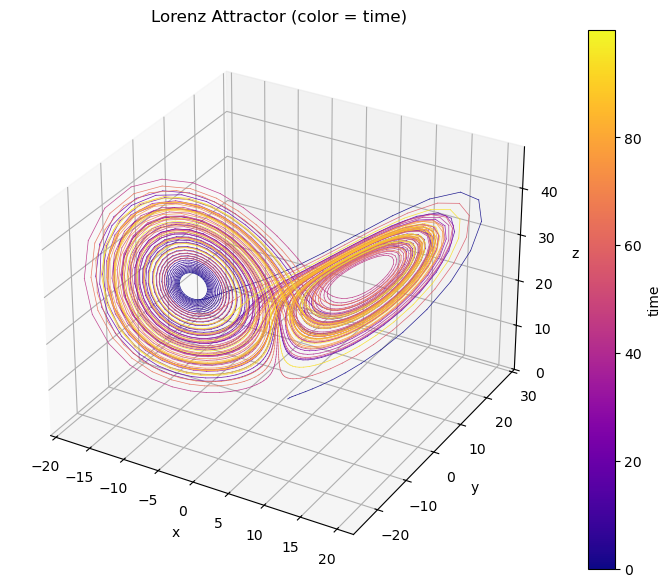

In [4]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

time_mask = (out_times < 100)
x, y, z = out[time_mask, 0], out[time_mask, 1], out[time_mask, 2]
t = out_times[time_mask]

# Normalize time for colormap
norm = plt.Normalize(t.min(), t.max())
cmap = plt.cm.plasma
colors = cmap(norm(t))

# Draw line as segments so each span can be colored by time
for i in range(len(x) - 1):
    ax.plot(x[i:i+2], y[i:i+2], z[i:i+2], color=colors[i], linewidth=0.5, alpha=0.9)

ax.set_title("Lorenz Attractor (color = time)")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
fig.colorbar(sm, ax=ax, label="time")

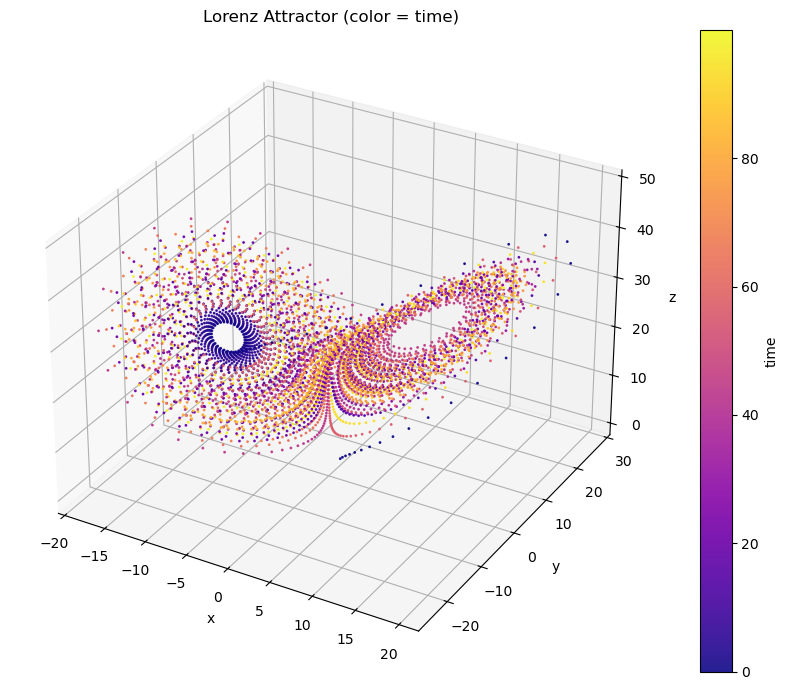

In [5]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

time_mask=(out_times<100)

sc = ax.scatter(
    out[time_mask, 0], out[time_mask, 1], out[time_mask, 2],
    c=out_times[time_mask], cmap='plasma', s=1, alpha=0.9
)

ax.set_title("Lorenz Attractor (color = time)")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
fig.colorbar(sc, ax=ax, label="time")

plt.tight_layout()
plt.show()

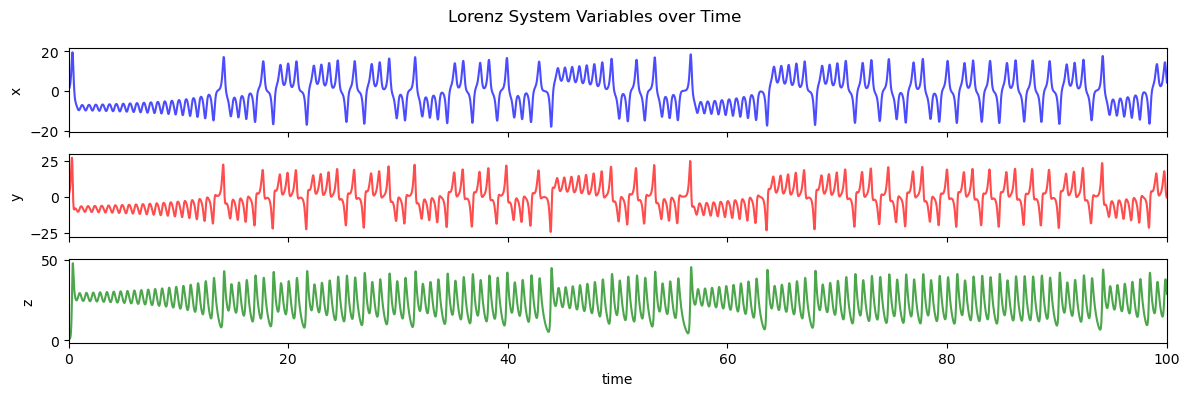

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(12, 4), sharex=True)

axes[0].plot(out_times, out[:, 0], color='blue', alpha=0.7)
axes[0].set_ylabel("x")

axes[1].plot(out_times, out[:, 1], color='red', alpha=0.7)
axes[1].set_ylabel("y")

axes[2].plot(out_times, out[:, 2], color='green', alpha=0.7)
axes[2].set_ylabel("z")
axes[2].set_xlabel("time")

axes[0].set_xlim(0,100)

fig.suptitle("Lorenz System Variables over Time")
plt.tight_layout()
plt.show()

In [7]:
x=out[out_times>100,:]
times=out_times[out_times>100]
import sklearn
scaler= sklearn.preprocessing.StandardScaler()
x_scaled = scaler.fit_transform(x)
print(x.shape)


(44999, 3)


In [8]:
def random_fourier_features(x: np.ndarray, D_out: int, sigma: float = 1.0, seed: int = None) -> np.ndarray:
    """
    Random Fourier Features (Rahimi & Recht, 2007) approximating the RBF kernel.

    Maps inputs x ~ [N, D] to z(x) ~ [N, 2*D_out] such that:
        z(x)ᵀ z(y)  ≈  k(x, y) = exp(-‖x - y‖² / (2σ²))

    Args:
        x:     Input array of shape [N, D], assumed normalized
        D_out: Number of random frequency samples (output dim = 2*D_out)
        sigma: RBF kernel bandwidth (default 1.0 for normalized inputs)
        seed:  Optional random seed for reproducibility

    Returns:
        z: Feature matrix of shape [N, 2*D_out]
    """
    rng = np.random.default_rng(seed)
    N, D = x.shape

    # Sample random frequencies from the spectral density of the RBF kernel:
    # p(w) = N(0, 1/σ² I)  (Fourier dual of the Gaussian kernel)
    W = rng.normal(loc=0.0, scale=1.0 / sigma, size=(D, D_out))  # [D, D_out]

    # Sample random phases uniformly in [0, 2π]
    b = rng.uniform(0, 2 * np.pi, size=(D_out,))                 # [D_out]

    # Project inputs: [N, D] @ [D, D_out] + [D_out] -> [N, D_out]
    z = x @ W + b                                                 # [N, D_out]

    # Approximate kernel via cos+sin embedding (variance-reduced form)
    # Using [cos, sin] avoids the random phase b and halves variance
    projection = x @ W                                            # [N, D_out]
    z = np.sqrt(1.0 / D_out) * np.concatenate(
        [np.cos(projection), np.sin(projection)], axis=1
    )                                                             # [N, 2*D_out]

    return z

In [9]:
x_koopman = random_fourier_features(x_scaled, D_out=500, sigma=0.1, seed=42)
x_koopman = np.hstack([x_scaled, x_koopman])  # Include original features for linear terms
print(x_koopman.shape)
#koopman_scaler= sklearn.preprocessing.StandardScaler()
#x_poly_scaled = poly_scaler.fit_transform(x_koopman)


(44999, 1003)


In [10]:
regressor = sklearn.linear_model.LinearRegression()
regressor.fit(x_koopman[:-1,:], x_koopman[1:,:])



LinearRegression()

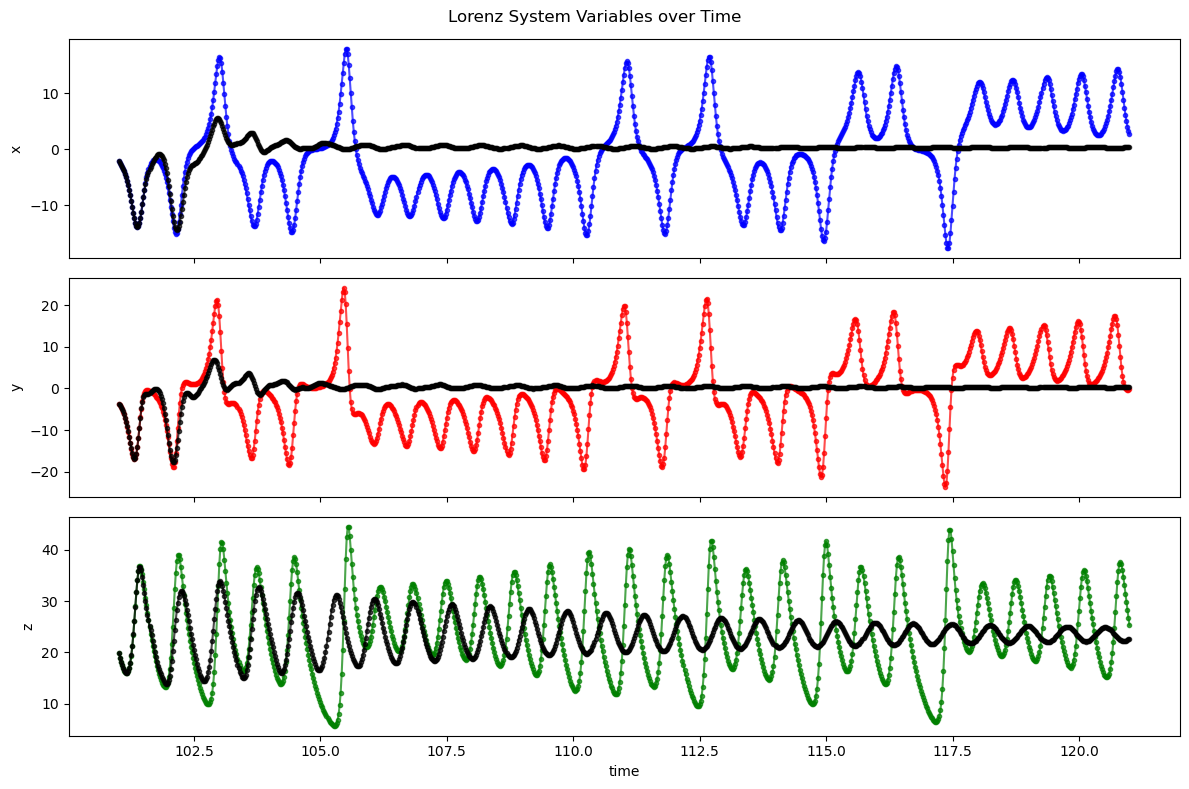

In [15]:
# choose sinitial condition and number of prediction steps
t_0 = 50
n_steps = 1000

x_koopman_pred = np.zeros_like(x_koopman[t_0:t_0+n_steps,:])
x_koopman_pred[0,:] = x_koopman[t_0,:]
for t in range(1, n_steps):
    x_koopman_pred[t,:] = regressor.predict(x_koopman_pred[t-1:t,:])

#x_koopman_pred_unscaled = koopman_scaler.inverse_transform(x_koopman_pred)
x_pred = scaler.inverse_transform(x_koopman_pred[:,:3])

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
axes[0].plot(times[t_0:t_0+n_steps], x[t_0:t_0+n_steps, 0], '.-', color='blue', alpha=0.7)
axes[0].plot(times[t_0:t_0+n_steps], x_pred[:, 0], '.-k',  alpha=0.7)
axes[0].set_ylabel("x")

axes[1].plot(times[t_0:t_0+n_steps], x[t_0:t_0+n_steps, 1], '.-', color='red', alpha=0.7)
axes[1].plot(times[t_0:t_0+n_steps], x_pred[:, 1], '.-k',  alpha=0.7)
axes[1].set_ylabel("y")

axes[2].plot(times[t_0:t_0+n_steps], x[t_0:t_0+n_steps, 2], '.-', color='green', alpha=0.7)
axes[2].plot(times[t_0:t_0+n_steps], x_pred[:, 2], '.-k',  alpha=0.7)
axes[2].set_ylabel("z")
axes[2].set_xlabel("time")

fig.suptitle("Lorenz System Variables over Time")
plt.tight_layout()
plt.show()